In [1]:
import pybamm
import ipywidgets as widgets
import matplotlib.pyplot as plt

# ----------------------
# 1. Define experiment
# ----------------------
cycle_steps = [
    ("Discharge at 2C until 3.4V",),
]
experiment = pybamm.Experiment(cycle_steps * 5)



In [2]:
# ----------------------
# 2. SPMe Model (Lumped Thermal)
# ----------------------
print("Running SPMe (lumped thermal)...")
spme_model = pybamm.lithium_ion.SPMe({"thermal": "lumped"})
spme_param = pybamm.ParameterValues("Marquis2019")
spme_sim = pybamm.Simulation(spme_model, parameter_values=spme_param, experiment=experiment)
spme_sim.solve()
spme_sol = spme_sim.solution

Running SPMe (lumped thermal)...


In [3]:
spme_sol.plot(["Terminal voltage [V]"])
spme_sol.plot(["X-averaged cell temperature [C]"])

#plot cell temeprature as a function of stochiometric coefficient


interactive(children=(FloatSlider(value=0.0, description='t', max=1688.240353713499, step=16.88240353713499), …

interactive(children=(FloatSlider(value=0.0, description='t', max=1688.240353713499, step=16.88240353713499), …

In [4]:
# ----------------------
# 4. DFN Model (x-full Thermal)
# ----------------------
print("Running DFN (x-full thermal)...")
dfn_model = pybamm.lithium_ion.DFN({"thermal": "x-full"})
dfn_param = pybamm.ParameterValues("Marquis2019")
dfn_sim = pybamm.Simulation(dfn_model, parameter_values=dfn_param, experiment=experiment)
dfn_sim.solve()
dfn_sol = dfn_sim.solution


Running DFN (x-full thermal)...


At t = 408.334 and h = 9.20273e-15, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 281.144 and h = 2.10278e-15, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 281.144 and h = 2.35101e-17, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 281.143 and h = 2.1529e-21, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 281.143 and h = 1.18302e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 281.143 and h = 1.59331e-22, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 281.143, , mxstep steps taken before reaching tout.
At t = 281.143, , mxstep steps taken before reaching tout.
At t = 281.143 and h = 4.93579e-22, the corrector convergence failed repeatedly or with |h| = hmin.


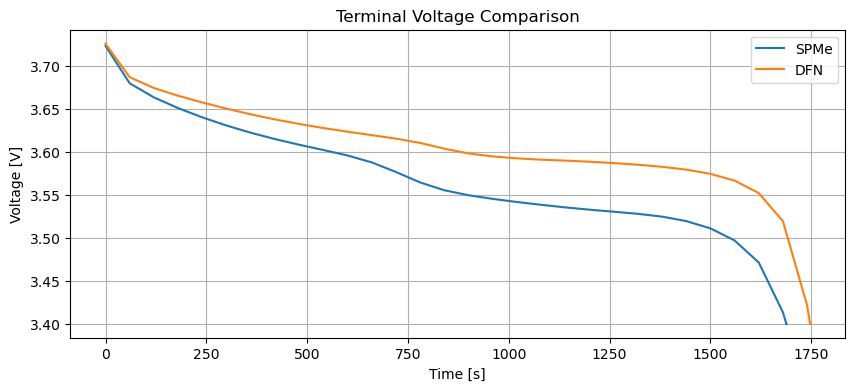

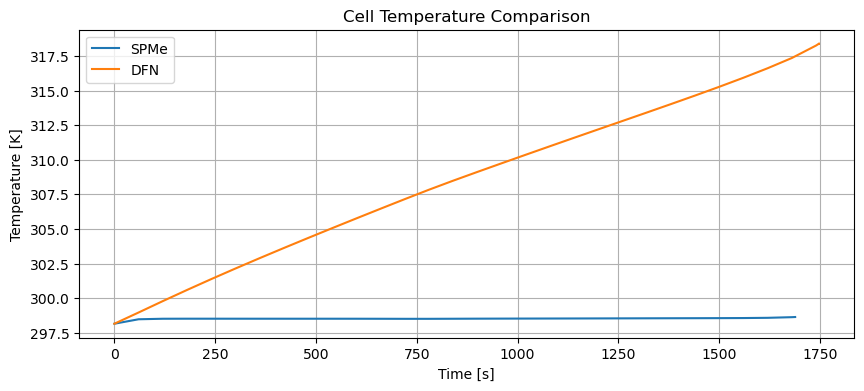

In [5]:
import matplotlib.pyplot as plt

# Extract time and data
t_spme = spme_sol["Time [s]"].entries
t_dfn = dfn_sol["Time [s]"].entries

V_spme = spme_sol["Terminal voltage [V]"].entries
V_dfn = dfn_sol["Terminal voltage [V]"].entries

T_spme = spme_sol["Volume-averaged cell temperature [K]"].entries
T_dfn = dfn_sol["Volume-averaged cell temperature [K]"].entries

# Plot voltage comparison
plt.figure(figsize=(10, 4))
plt.plot(t_spme, V_spme, label="SPMe", linewidth=1.5)
plt.plot(t_dfn, V_dfn, label="DFN", linewidth=1.5)
plt.title("Terminal Voltage Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.legend()
plt.grid(True)

# Plot temperature comparison
plt.figure(figsize=(10, 4))
plt.plot(t_spme, T_spme, label="SPMe", linewidth=1.5)
plt.plot(t_dfn, T_dfn, label="DFN", linewidth=1.5)
plt.title("Cell Temperature Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.legend()
plt.grid(True)

plt.show()
